Using device: cuda
Train size: 298560
Val size:   53629
Malignant: 271 | Benign: 298289 | pos_weight: 1100.70
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 234MB/s]



PHASE 1: Training Classifier Head


Epoch 1/2: 100%|██████████| 4665/4665 [26:20<00:00,  2.95it/s]


Epoch  1 | Loss: 1.3271 | AUROC: 0.8144 | PR-AUC: 0.00742 | Sens@95%Spec: 0.3509 | Acc@best: 0.9953


...

Epoch  4 | Loss: 0.9507 | AUROC: 0.8412 | PR-AUC: 0.01382 | Sens@95%Spec: 0.4912 | Acc@best: 0.9967


Epoch 5/6: 100%|██████████| 4665/4665 [09:20<00:00,  8.33it/s]


Epoch  5 | Loss: 0.9722 | AUROC: 0.8895 | PR-AUC: 0.01228 | Sens@95%Spec: 0.6316 | Acc@best: 0.9871


Epoch 6/6: 100%|██████████| 4665/4665 [09:18<00:00,  8.35it/s]


Epoch  6 | Loss: 0.9882 | AUROC: 0.8835 | PR-AUC: 0.03534 | Sens@95%Spec: 0.5965 | Acc@best: 0.9979


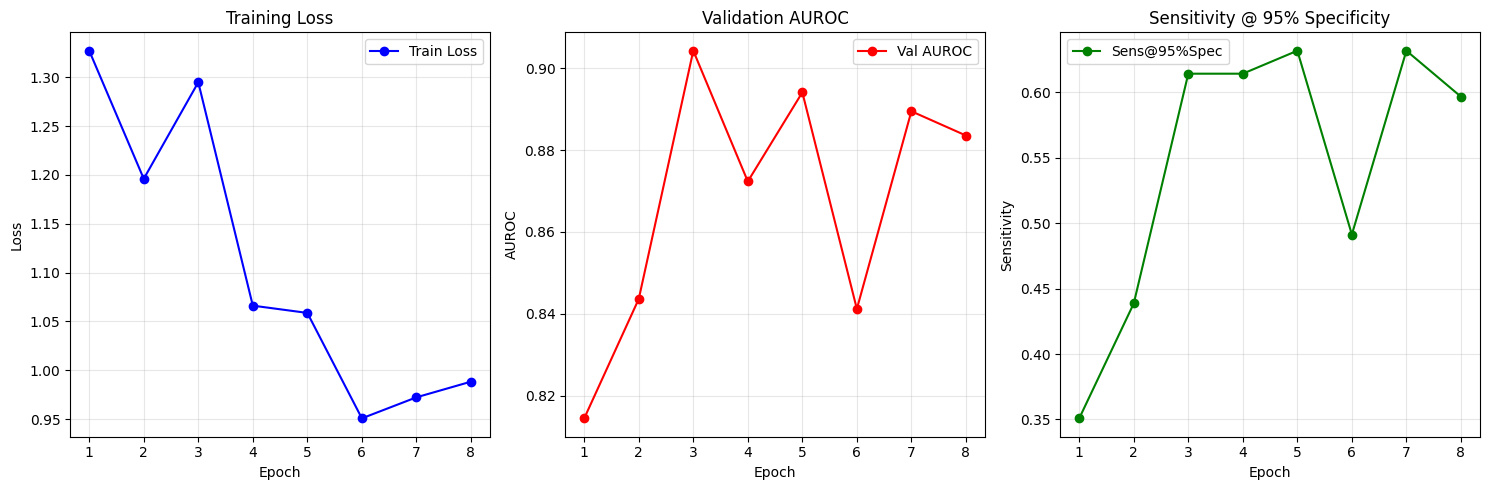


TRAINING COMPLETED SUCCESSFULLY!
Best Validation AUROC: 0.9043


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image
import os
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve,
                             accuracy_score)
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import matplotlib.pyplot as plt

CONFIG = {
    "img_size": 224,
    "batch_size": 64,
    "epochs_head": 2,
    "epochs_full": 6,
    "lr_head": 1e-3,
    "lr_full": 1e-4,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

INDEX_PATH = "/kaggle/input/datasets/fallen001/final-dataset-index/final_dataset_index.csv"

print("Using device:", CONFIG["device"])

df = pd.read_csv(INDEX_PATH)
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")

# Weighted loss
num_malignant = train_df["target"].sum()
num_benign = len(train_df) - num_malignant
pos_weight_value = num_benign / num_malignant
print(f"Malignant: {num_malignant} | Benign: {num_benign} | pos_weight: {pos_weight_value:.2f}")

class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.base_dir = "/kaggle/input/competitions/isic-2024-challenge/train-image/image"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = os.path.basename(row["path"])
        img_path = os.path.join(self.base_dir, filename)

        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            image = self.transform(image=image)["image"]

        label = torch.tensor(row["target"], dtype=torch.float32)
        return image, label

# Transforms
train_transforms = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(CONFIG["img_size"], CONFIG["img_size"]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# DataLoaders
train_loader = DataLoader(ISICDataset(train_df, train_transforms),
                          batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2)
val_loader   = DataLoader(ISICDataset(val_df, val_transforms),
                          batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2)

model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(CONFIG["device"])

pos_weight = torch.tensor([pos_weight_value]).to(CONFIG["device"])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def evaluate(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(CONFIG["device"])
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    probs = np.array(all_probs)
    labels = np.array(all_labels)

    auc = roc_auc_score(labels, probs)
    pr_auc = average_precision_score(labels, probs)

    # Sensitivity @ 95% Specificity
    fpr, tpr, _ = roc_curve(labels, probs)
    idx = np.where(fpr <= 0.05)[0]
    sens95 = tpr[idx[-1]] if len(idx) > 0 else 0.0

    # Best threshold (max F1)
    prec, rec, thresh = precision_recall_curve(labels, probs)
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)
    best_idx = np.argmax(f1)
    best_thresh = thresh[best_idx]

    preds_best = (probs >= best_thresh).astype(int)
    acc_best = accuracy_score(labels, preds_best)

    return {
        'auc': auc,
        'pr_auc': pr_auc,
        'sens95': sens95,
        'accuracy_best': acc_best,
        'best_threshold': best_thresh
    }

history = {'train_loss': [], 'val_auc': [], 'val_prauc': [], 'val_sens95': []}

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=CONFIG["lr_head"])

print("\n" + "="*60)
print("PHASE 1: Training Classifier Head")
print("="*60)

for epoch in range(CONFIG["epochs_head"]):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs_head']}"):
        images = images.to(CONFIG["device"])
        labels = labels.unsqueeze(1).to(CONFIG["device"])

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    metrics = evaluate(model, val_loader)

    history['train_loss'].append(running_loss / len(train_loader))
    history['val_auc'].append(metrics['auc'])
    history['val_prauc'].append(metrics['pr_auc'])
    history['val_sens95'].append(metrics['sens95'])

    print(f"Epoch {epoch+1:2d} | Loss: {running_loss/len(train_loader):.4f} | "
          f"AUROC: {metrics['auc']:.4f} | PR-AUC: {metrics['pr_auc']:.5f} | "
          f"Sens@95%Spec: {metrics['sens95']:.4f} | Acc@best: {metrics['accuracy_best']:.4f}")

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr_full"])
best_auc = 0.0

print("\n" + "="*60)
print("PHASE 2: Fine-tuning Full Network")
print("="*60)

for epoch in range(CONFIG["epochs_full"]):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs_full']}"):
        images = images.to(CONFIG["device"])
        labels = labels.unsqueeze(1).to(CONFIG["device"])

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    metrics = evaluate(model, val_loader)

    history['train_loss'].append(running_loss / len(train_loader))
    history['val_auc'].append(metrics['auc'])
    history['val_prauc'].append(metrics['pr_auc'])
    history['val_sens95'].append(metrics['sens95'])

    print(f"Epoch {epoch+1:2d} | Loss: {running_loss/len(train_loader):.4f} | "
          f"AUROC: {metrics['auc']:.4f} | PR-AUC: {metrics['pr_auc']:.5f} | "
          f"Sens@95%Spec: {metrics['sens95']:.4f} | Acc@best: {metrics['accuracy_best']:.4f}")

    if metrics['auc'] > best_auc:
        best_auc = metrics['auc']
        torch.save(model.state_dict(), "best_resnet18_isic2024.pth")
        print(f"   → New best model saved! (AUROC: {best_auc:.4f})")

plt.figure(figsize=(15, 5))

# Loss Curve
plt.subplot(1, 3, 1)
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'b-o', label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# AUROC Curve
plt.subplot(1, 3, 2)
plt.plot(range(1, len(history['val_auc'])+1), history['val_auc'], 'r-o', label='Val AUROC')
plt.title('Validation AUROC')
plt.xlabel('Epoch')
plt.ylabel('AUROC')
plt.legend()
plt.grid(True, alpha=0.3)

# Sensitivity @ 95% Spec
plt.subplot(1, 3, 3)
plt.plot(range(1, len(history['val_sens95'])+1), history['val_sens95'], 'g-o', label='Sens@95%Spec')
plt.title('Sensitivity @ 95% Specificity')
plt.xlabel('Epoch')
plt.ylabel('Sensitivity')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TRAINING COMPLETED SUCCESSFULLY!")
print(f"Best Validation AUROC: {best_auc:.4f}")
print("="*60)